In [10]:
import numpy as np
import matplotlib.pyplot as plt

In [11]:
#fungsi yang dicari akarnya
#f(x) = 1/2 * x * e^(x^(0,5)) - 2
def f(x):
    return 0.5 * x * np.exp(np.sqrt(x)) - 2

In [12]:
# xi batas bawah
# xu batas atas
# ea approximate error
# es error toleransi
def regulafalsi(xi, xu, ea, es):
    #inisialisasi variabel
    list_error = []
    list_xr = []
    list_x = []
    iter = 0

    #selama ea lebih besar dari es, lanjutkan iterasi
    while(ea > es):
        #tambah iterasi & tambahkan nilai iter ke list_x
        iter += 1
        list_x.append(iter)
        #tampilkan iterasi, xi , xu, f(xi), f(xu). batesin 4 angka belakang koma
        print(f"Iterasi ke {iter}")
        print(f"xi : {xi:.4f}, {xu:.4f}")
        print(f"f(xi): {f(xi):.4f} f(xu): {f(xu):.4f}")

        #rumus regulafalsi
        xr = xu - (f(xu) * (xi-xu))/ (f(xi)-f(xu))
        print(f"xr: {xr:.4f}")
        print(f"f(xr): {f(xr):.4f}")

        #hitung approximate error(ea) kalau udah iterasi 2
        if(iter>1):
            ea = abs((xr - xr_old)/xr)*100 #rumus approximate error
            print(f"ea : {ea:.4f}")
            list_error.append(ea)

        #kalau f(xi) * f(xr) < 0, maka akar berada di antara xi dan xr, maka xu = xr
        if(f(xi)*f(xr)<0):
            xu = xr
        #kalau f(xi)*f(xr) > 0, maka akar berada di antara xr dan xu, maka xi = xr
        elif(f(xi)*f(xr)>0):
            xi = xr
        else:
            break


        #tambahkan xr ke akhir list_xr
        list_xr.append(xr)
        #simpan nilai xr sekarang ke xr_old
        xr_old = xr
    
    return list_error, list_xr, list_x

In [16]:
list_error, list_xr, list_x = regulafalsi(0.5, 1.5, 100, 4)

Iterasi ke 1
xi : 0.5000, 1.5000
f(xi): -1.4930 f(xu): 0.5525
xr: 1.2299
f(xr): -0.1359
Iterasi ke 2
xi : 1.2299, 1.5000
f(xi): -0.1359 f(xu): 0.5525
xr: 1.2832
f(xr): -0.0083
ea : 4.1547
Iterasi ke 3
xi : 1.2832, 1.5000
f(xi): -0.0083 f(xu): 0.5525
xr: 1.2864
f(xr): -0.0005
ea : 0.2481


<function matplotlib.pyplot.show(close=None, block=None)>

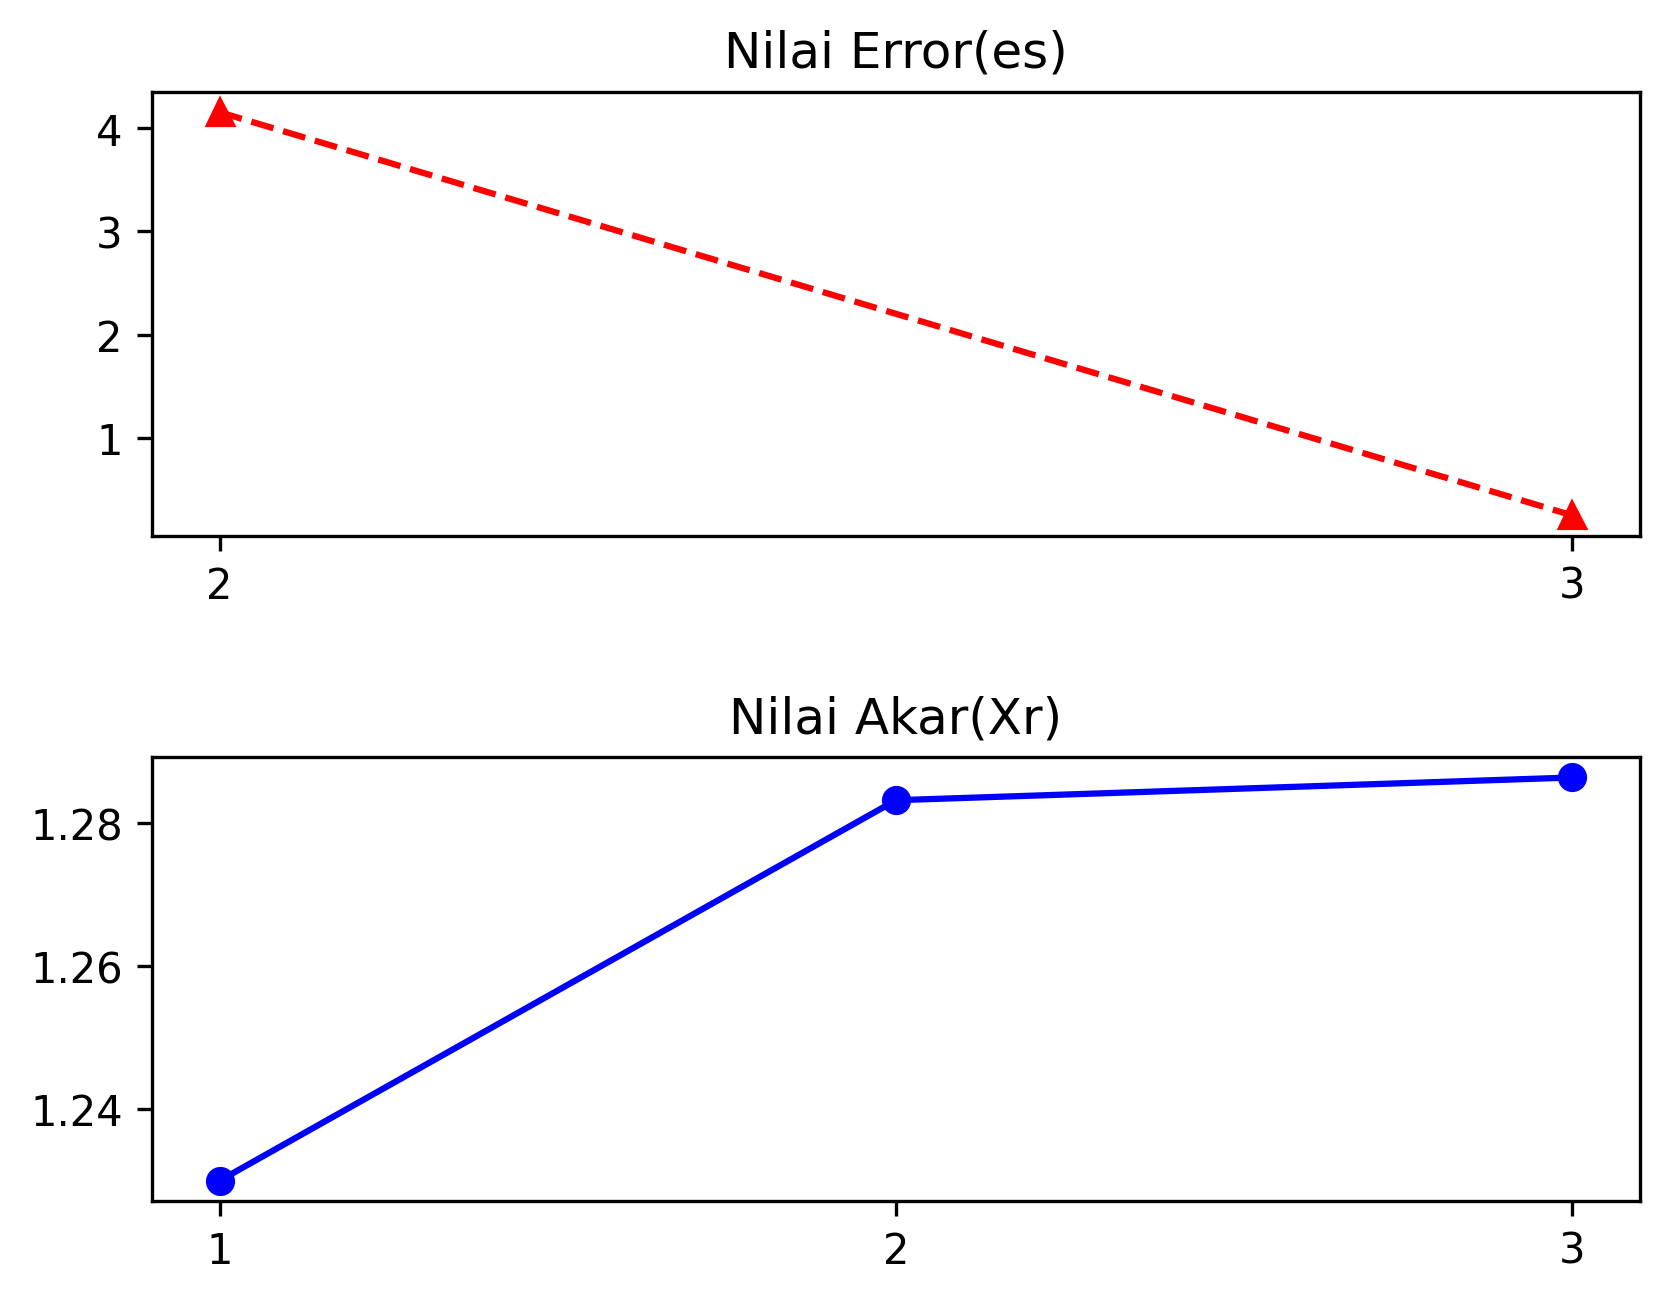

In [ ]:
plt.figure(dpi=300)
#subplot 1
plt.subplot(211)
#nilai x nya list_x, nilai y nya list_error
#[1:] ambil iterasi mulai dari indeks ke -1 (iterasi 2)
plt.plot(list_x[1:], list_error, "r--", list_x[1:], list_error, "r^")
#judul subplot 1
plt.title("Nilai Error(es)")
#angka di sumbu x
plt.xticks(list_x[1:])

#subplot 2
plt.subplot(212)
#nilai x nya list_x, nilai y nya list_xr
plt.plot(list_x, list_xr, "bo", list_x, list_xr, "b")
#judul subplot 2
plt.title("Nilai Akar(Xr)")
#angka di sumbu x
plt.xticks(list_x)
#atur jarak vertikal antar subplot/grafik
plt.subplots_adjust(hspace=0.5)
#tampilkan
plt.show